Importing All The Dependencies 

In [20]:
import os
import xml.etree.ElementTree as ET
from collections import Counter 
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm
import cv2
import random

Dataset Folder 

In [21]:
Train_Img_Path = r"C:\Users\kiran\Downloads\archive\dataset-splitM\Training\images"
Train_Mask_Path = r"C:\Users\kiran\Downloads\archive\dataset-splitM\Training\GT"

Test_Img_Path = r"C:\Users\kiran\Downloads\archive\dataset-splitM\Testing\images"
Test_Mask_Path = r"C:\Users\kiran\Downloads\archive\dataset-splitM\Testing\GT"

In [26]:
def get_stems(folder):
    return set(Path(f).stem for f in os.listdir(folder))

train_img = get_stems(Train_Img_Path)
train_mask = get_stems(Train_Mask_Path) 

test_img = get_stems(Test_Img_Path)
test_mask = get_stems(Test_Mask_Path)   

print("TRAIN")
print("Images :", len(train_img))
print("Masks :", len(train_mask))
print("Missing Masks", len(train_img - train_mask))
print("Missing Images", len(train_mask - train_img))

print("TEST")
print("Images :", len(test_img))
print("Masks :", len(test_mask))
print("Missing Masks", len(test_img - test_mask))
print("Missing Images", len(test_mask - test_img))

TRAIN
Images : 748
Masks : 748
Missing Masks 0
Missing Images 0
TEST
Images : 330
Masks : 330
Missing Masks 0
Missing Images 0


In [27]:
img_stats = []
for folder in [Train_Img_Path, Test_Img_Path]:
    for img_file in tqdm(os.listdir(folder)):
        img_path = os.path.join(folder, img_file)
        img = cv2.imread(img_path)
        img_stats.append({
            "folder": os.path.basename(folder),
            "width": img.shape[1],
            "height": img.shape[0],
            "aspect_ratio": img.shape[1] / img.shape[0]
        })  

resolution_df = pd.DataFrame(img_stats)
resolution_df.head()

100%|██████████| 330/330 [00:03<00:00, 84.41it/s] 


,folder,width,height,aspect_ratio
0,images,303,500,0.606000
1,images,720,430,1.674419
2,images,1280,720,1.777778
3,images,800,558,1.433692
4,images,375,500,0.750000


In [28]:
resolution_df.describe()

,width,height,aspect_ratio
count,1078.000000,1078.000000,1078.000000
mean,1054.990724,840.514842,1.308848
std,459.907071,402.814047,0.391117
min,209.000000,180.000000,0.510783
25%,750.000000,649.500000,1.000000
50%,1000.500000,720.000000,1.333333
75%,1280.000000,960.000000,1.777778
max,4775.000000,5472.000000,2.250879


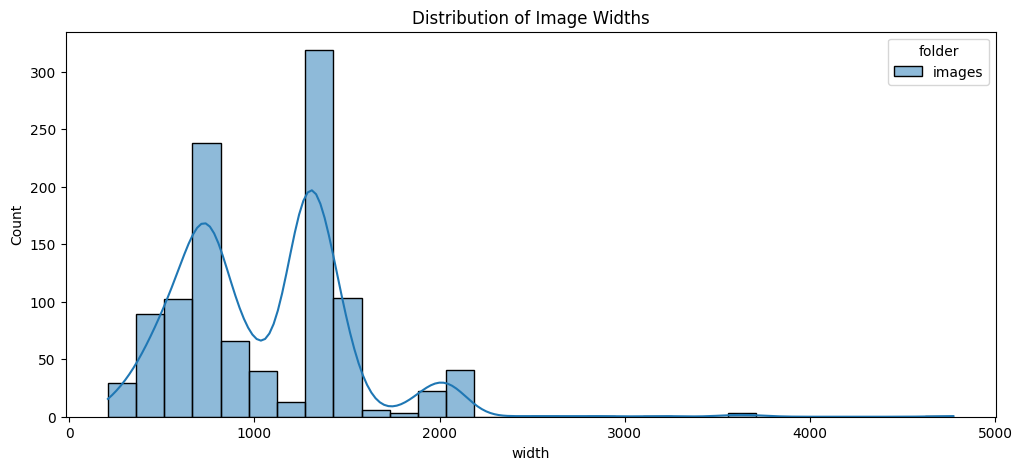

In [29]:
plt.figure(figsize=(12, 5))
sns.histplot(data=resolution_df, x="width", hue="folder", bins=30, kde=True)
plt.title("Distribution of Image Widths")   
plt.show()

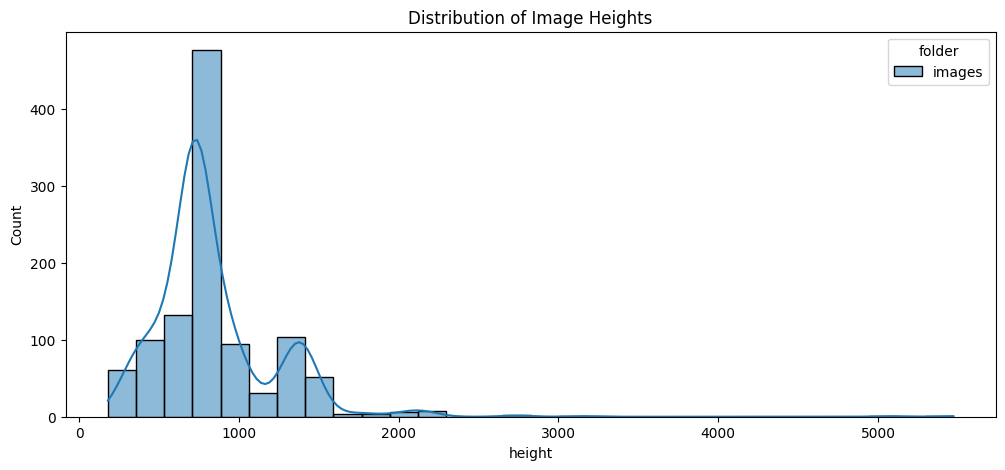

In [30]:
plt.figure(figsize=(12, 5))
sns.histplot(data=resolution_df, x="height", hue="folder", bins=30, kde=True)
plt.title("Distribution of Image Heights")
plt.show()  

Mask Coverage Analysis

In [32]:
coverage_data =[]
for folder in [Train_Img_Path, Test_Img_Path]:
    for img_file in tqdm(os.listdir(folder)):
        img_path = os.path.join(folder, img_file)
        mask = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        total_pixels = mask.size
        foreground_pixels = np.sum(mask > 0)
        coverage = foreground_pixels / total_pixels
        coverage_data.append(coverage)
coverage_df = pd.DataFrame({'coverage': coverage_data})
coverage_df.head()

100%|██████████| 330/330 [00:02<00:00, 152.97it/s]


,coverage
0,0.974904
1,0.998424
2,0.999470
3,0.992500
4,0.999360


In [33]:
coverage_df.describe()

,coverage
count,1078.000000
mean,0.982574
std,0.054598
min,0.704080
25%,0.995712
50%,0.999061
75%,0.999952
max,1.000000


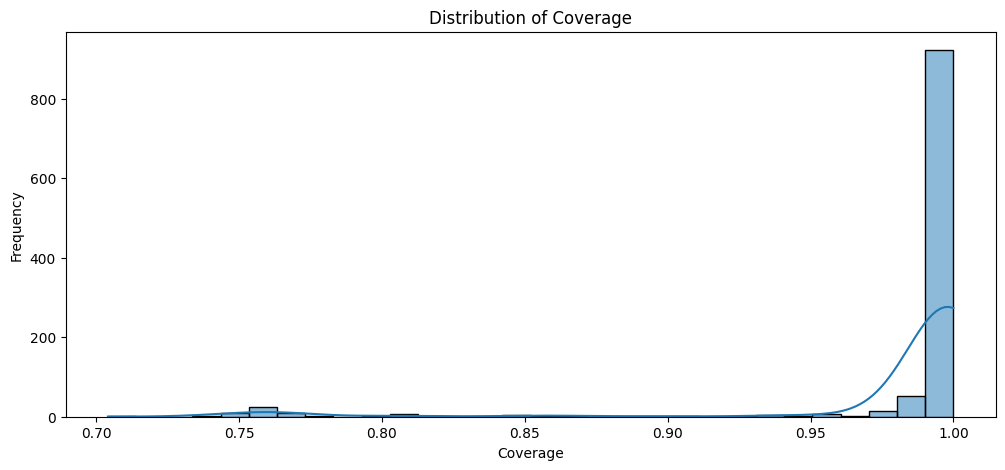

In [34]:
plt.figure(figsize=(12, 5))
sns.histplot(data=coverage_df, x='coverage', bins=30, kde=True)
plt.title("Distribution of Coverage")
plt.xlabel("Coverage")
plt.ylabel("Frequency")
plt.show()